In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Đọc dữ liệu
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

Kích thước tập Train: (8693, 14)
Kích thước tập Test: (4277, 13)


In [57]:
train_df.info()

# Tính toán tỷ lệ phần trăm khuyết thiếu trên mỗi cột
missing_train = train_df.isnull().sum() / len(train_df) * 100
missing_test = test_df.isnull().sum() / len(test_df) * 100

missing_df = pd.DataFrame({
    'Train Missing (%)': missing_train,
    'Test Missing (%)': missing_test
})

print("\nTỷ lệ khuyết thiếu (%) ở từng cột:")
display(missing_df.round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

Tỷ lệ khuyết thiếu (%) ở từng cột:


,Train Missing (%),Test Missing (%)
Age,2.06,2.13
Cabin,2.29,2.34
CryoSleep,2.50,2.17
Destination,2.09,2.15
FoodCourt,2.11,2.48
HomePlanet,2.31,2.03
Name,2.30,2.20
PassengerId,0.00,0.00
RoomService,2.08,1.92
ShoppingMall,2.39,2.29


C:\Users\HP\AppData\Local\Temp\ipykernel_11044\672139886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


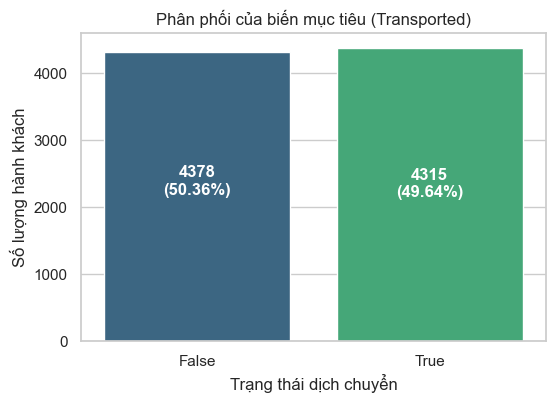

In [58]:
target_counts = train_df['Transported'].value_counts()
target_pct = train_df['Transported'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Phân phối của biến mục tiêu (Transported)')
plt.ylabel('Số lượng hành khách')
plt.xlabel('Trạng thái dịch chuyển')

for i, val in enumerate(target_counts.values):
    plt.text(i, val/2, f"{val}\n({target_pct.values[i]:.2f}%)", ha='center', color='white', fontweight='bold')

plt.show()

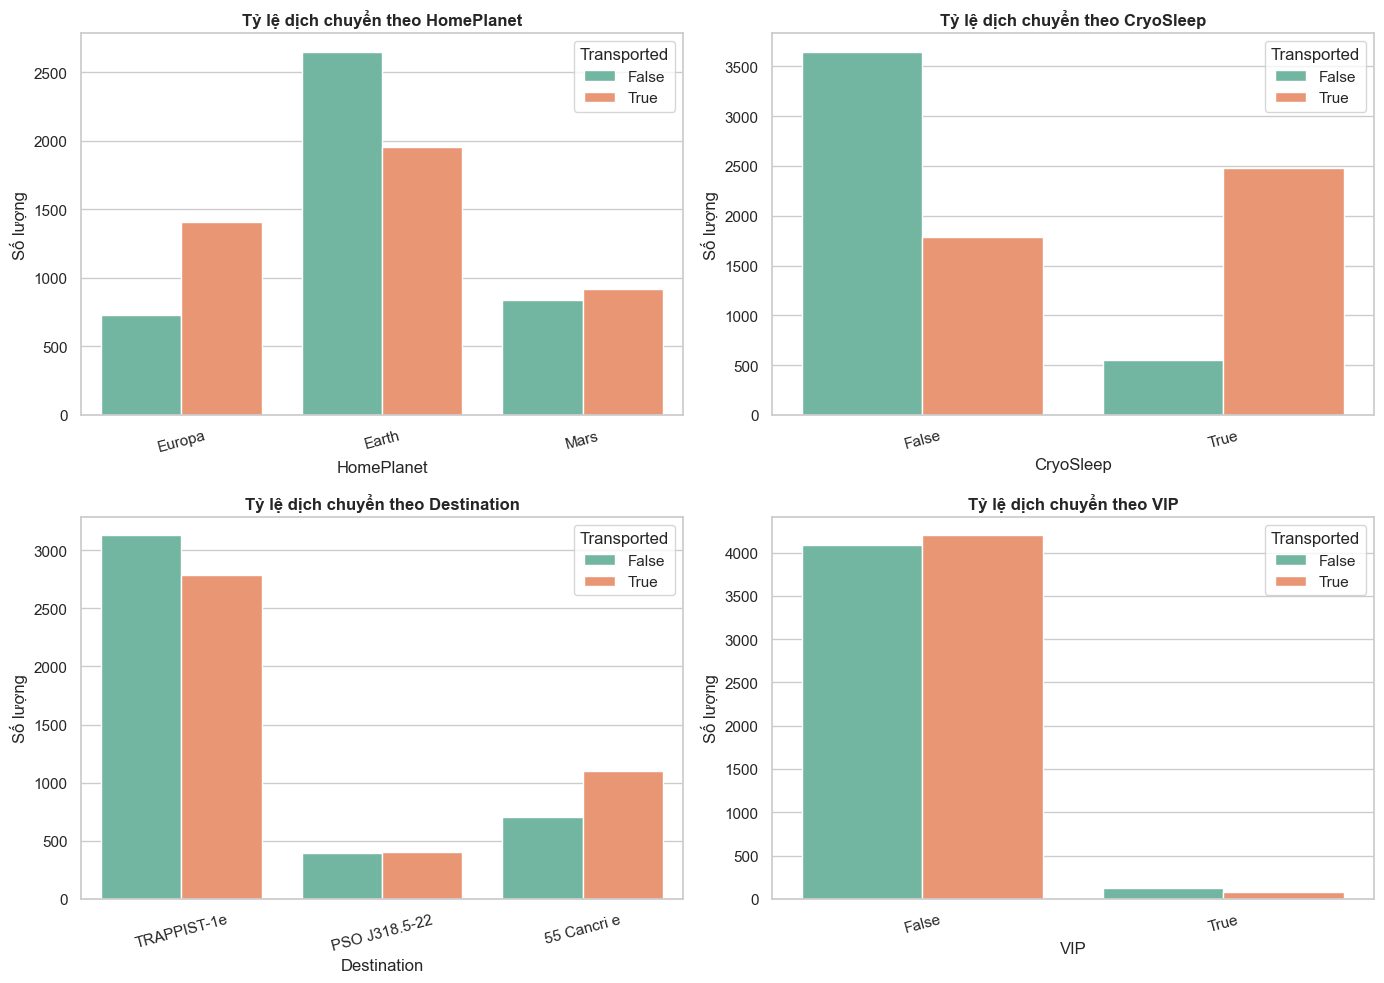

In [59]:
raw_cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# Tạo lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(raw_cat_cols):
    sns.countplot(data=train_df, x=col, hue='Transported', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Tỷ lệ dịch chuyển theo {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Số lượng')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

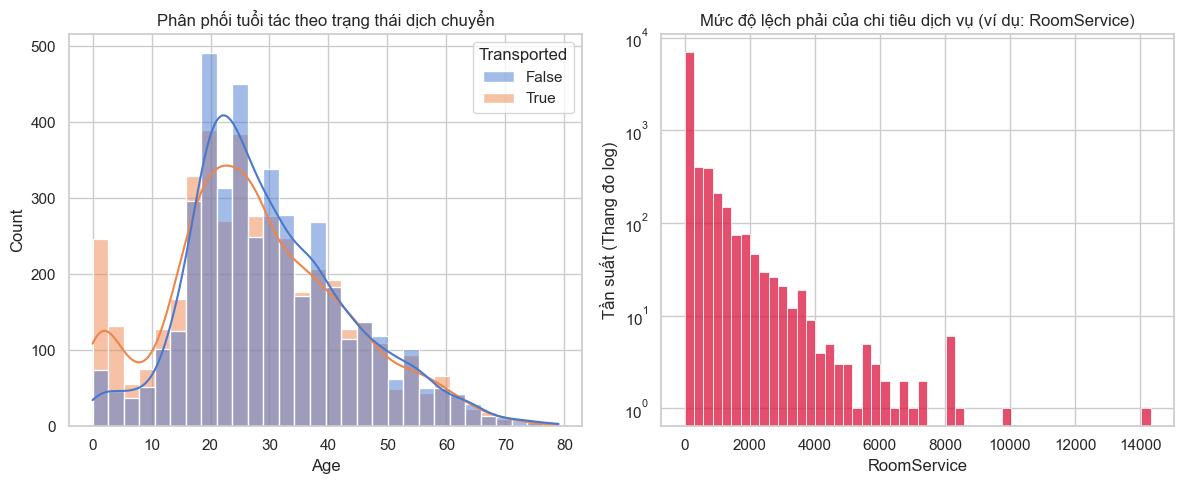

In [60]:
# Trực quan hóa phân phối Tuổi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, bins=30, palette='muted')
plt.title('Phân phối tuổi tác theo trạng thái dịch chuyển')

# Trực quan hóa phân phối một cột chi tiêu điển hình (ví dụ: RoomService)
plt.subplot(1, 2, 2)
sns.histplot(data=train_df, x='RoomService', kde=False, bins=50, color='crimson')
plt.title('Mức độ lệch phải của chi tiêu dịch vụ (ví dụ: RoomService)')
plt.yscale('log') 
plt.ylabel('Tần suất (Thang đo log)')

plt.tight_layout()
plt.show()

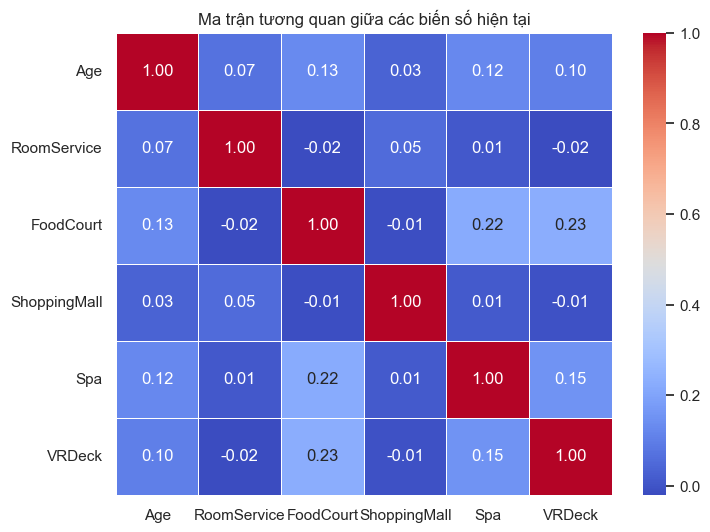

In [61]:
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số hiện tại')
plt.show()

# Bước 2: Feature Engineering
Dựa trên kết quả EDA, chúng ta tiến hành xây dựng các đặc trưng mới nhằm cung cấp thêm thông tin hữu ích cho mô hình:
1. **Tách mã nhóm (`Group` & `GroupSize`)**: Từ `PassengerId` dạng `gggg_pp`, ta lấy `gggg` làm mã nhóm và tính toán sĩ số nhóm hành khách đi cùng nhau.
2. **Xác định khách đi đơn lẻ (`Solo`)**: Hành khách đi một mình (`GroupSize == 1`) có thể có hành vi và vị trí khác với nhóm gia đình.
3. **Tách thông tin Cabin (`Cabin_deck`, `Cabin_num`, `Cabin_side`)**: Cấu trúc Cabin `deck/num/side` được phân rã để mô hình học được vị trí vật lý của hành khách trên tàu.
4. **Họ của hành khách (`LastName`)**: Trích xuất từ cột `Name` để xác định các thành viên cùng gia đình.
5. **Tổng chi tiêu (`TotalSpend`)**: Cộng gộp 5 khoản chi tiêu dịch vụ.
6. **Chỉ thị không chi tiêu (`NoSpending`)**: Biến phân loại nhị phân biểu thị hành khách không sử dụng bất kỳ dịch vụ trả phí nào (thường là người ngủ đông).
7. **Phân nhóm độ tuổi (`AgeGroup`)**: Chuyển biến tuổi liên tục thành các khoảng tuổi có ý nghĩa hành vi (trẻ em, thanh thiếu niên, trung niên, người già).
8. **Biến đổi Log (`Log-transform`)**: Áp dụng `np.log1p` cho các cột chi tiêu để giảm độ lệch phải (skewness).

In [62]:
y_train = train_df['Transported'].astype(int)
train_len = len(train_df)

# Gộp tạm thời Train và Test (bỏ cột mục tiêu) để biến đổi đồng bộ
df_all = pd.concat([train_df, test_df], ignore_index=True)

print(f"Tổng số mẫu sau khi gộp để xử lý: {df_all.shape[0]}")

Tổng số mẫu sau khi gộp để xử lý: 12970


In [63]:
df_all['Group'] = df_all['PassengerId'].apply(lambda x: x.split('_')[0])
group_sizes = df_all['Group'].value_counts().to_dict()
df_all['GroupSize'] = df_all['Group'].map(group_sizes)

# 2. Xác định hành khách đi một mình (Solo)
df_all['Solo'] = (df_all['GroupSize'] == 1).astype(int)

# 3. Tách cột Cabin 
df_all['Cabin'] = df_all['Cabin'].fillna('Missing/9999/Missing')
df_all['Cabin_deck'] = df_all['Cabin'].apply(lambda x: x.split('/')[0])
df_all['Cabin_num'] = df_all['Cabin'].apply(lambda x: int(x.split('/')[1]))
df_all['Cabin_side'] = df_all['Cabin'].apply(lambda x: x.split('/')[2])

# Trả lại giá trị NaN cho các phần được tách từ Cabin thiếu thực sự
df_all.loc[df_all['Cabin_deck'] == 'Missing', 'Cabin_deck'] = np.nan
df_all.loc[df_all['Cabin_num'] == 9999, 'Cabin_num'] = np.nan
df_all.loc[df_all['Cabin_side'] == 'Missing', 'Cabin_side'] = np.nan

# 4. Trích xuất Họ (LastName) từ Name
df_all['Name'] = df_all['Name'].fillna('Unknown Unknown')
df_all['LastName'] = df_all['Name'].apply(lambda x: x.split()[-1])
df_all.loc[df_all['LastName'] == 'Unknown', 'LastName'] = np.nan

In [64]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# Tạm thời điền khuyết bằng 0 để cộng tổng (bước Imputation thực tế sẽ tối ưu hóa sau)
df_all['TotalSpend'] = df_all[spend_cols].fillna(0).sum(axis=1)

# 6. Tạo biến chỉ thị Không chi tiêu (NoSpending)
df_all['NoSpending'] = (df_all['TotalSpend'] == 0).astype(int)

# 7. Phân nhóm độ tuổi (AgeGroup)
df_all['AgeGroup'] = pd.cut(
    df_all['Age'], 
    bins=[-1, 12, 18, 30, 50, 100], 
    labels=['Child', 'Teenager', 'Young_Adult', 'Middle_Aged', 'Senior']
)

# 8. Áp dụng Log1p Transform cho các biến chi tiêu để giảm độ lệch phân phối (Skewness)
for col in spend_cols + ['TotalSpend']:
    df_all[f'Log_{col}'] = np.log1p(df_all[col].fillna(0))

print("Các cột mới được tạo ra thành công!")
display(df_all[['Group', 'GroupSize', 'Solo', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'TotalSpend', 'NoSpending', 'AgeGroup', 'Log_TotalSpend']].head())


pd.set_option('display.max_columns', None)

print("\n\nBảng preview đầy đủ tất cả các cột:")
display(df_all.head())

Các cột mới được tạo ra thành công!


,Group,GroupSize,Solo,Cabin_deck,Cabin_num,Cabin_side,TotalSpend,NoSpending,AgeGroup,Log_TotalSpend
0,0001,1,1,B,0.0,P,0.0,1,Middle_Aged,0.000000
1,0002,1,1,F,0.0,S,736.0,0,Young_Adult,6.602588
2,0003,2,0,A,0.0,S,10383.0,0,Senior,9.248021
3,0003,2,0,A,0.0,S,5176.0,0,Middle_Aged,8.551981
4,0004,1,1,F,1.0,S,1091.0,0,Teenager,6.995766




Bảng preview đầy đủ tất cả các cột:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,GroupSize,Solo,Cabin_deck,Cabin_num,Cabin_side,LastName,TotalSpend,NoSpending,AgeGroup,Log_RoomService,Log_FoodCourt,Log_ShoppingMall,Log_Spa,Log_VRDeck,Log_TotalSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,1,1,B,0.0,P,Ofracculy,0.0,1,Middle_Aged,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,1,1,F,0.0,S,Vines,736.0,0,Young_Adult,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,2,0,A,0.0,S,Susent,10383.0,0,Senior,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,2,0,A,0.0,S,Susent,5176.0,0,Middle_Aged,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,1,1,F,1.0,S,Santantines,1091.0,0,Teenager,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766


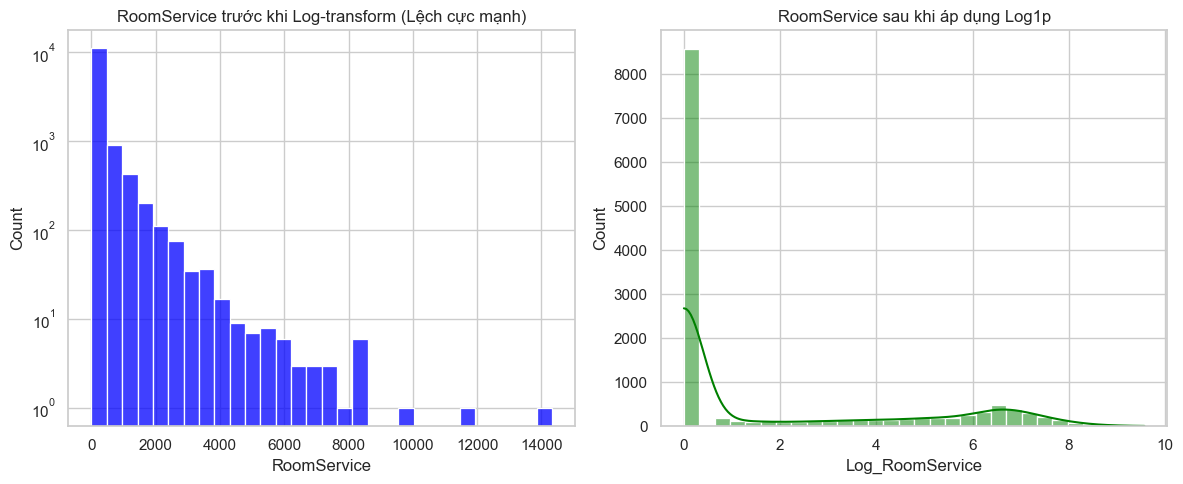

In [65]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_all['RoomService'].fillna(0), bins=30, kde=False, color='blue')
plt.title('RoomService trước khi Log-transform (Lệch cực mạnh)')
plt.yscale('log')

plt.subplot(1, 2, 2)
sns.histplot(df_all['Log_RoomService'], bins=30, kde=True, color='green')
plt.title('RoomService sau khi áp dụng Log1p')

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11044\3197542684.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Đi theo nhóm (0)', 'Đi một mình (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\3197542684.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Có tiêu tiền (0)', 'Không tiêu tiền (1)'])


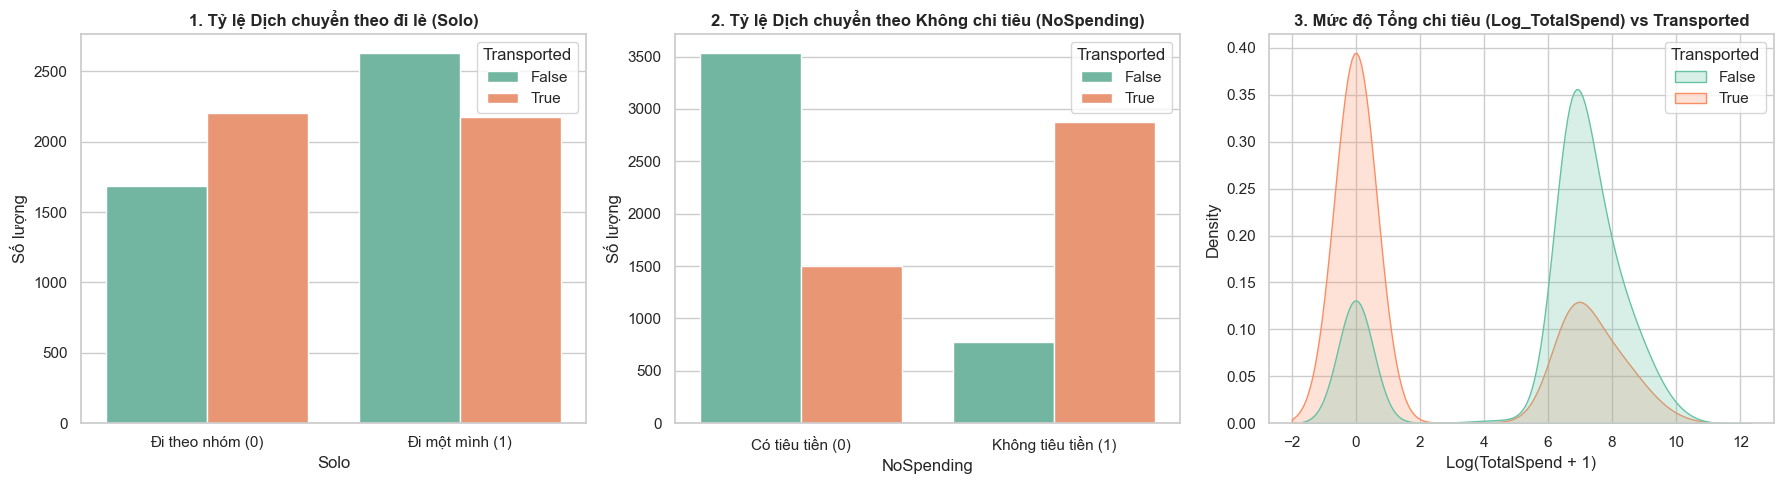

In [66]:
train_features = df_all[df_all['Transported'].notnull()].copy()
train_features['Transported'] = train_features['Transported'].astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tỷ lệ Dịch chuyển theo cột đi một mình (Solo)
sns.countplot(data=train_features, x='Solo', hue='Transported', ax=axes[0], palette='Set2')
axes[0].set_title('1. Tỷ lệ Dịch chuyển theo đi lẻ (Solo)', fontweight='bold')
axes[0].set_xticklabels(['Đi theo nhóm (0)', 'Đi một mình (1)'])
axes[0].set_ylabel('Số lượng')

# 2. Tỷ lệ Dịch chuyển theo Không chi tiêu (NoSpending)
sns.countplot(data=train_features, x='NoSpending', hue='Transported', ax=axes[1], palette='Set2')
axes[1].set_title('2. Tỷ lệ Dịch chuyển theo Không chi tiêu (NoSpending)', fontweight='bold')
axes[1].set_xticklabels(['Có tiêu tiền (0)', 'Không tiêu tiền (1)'])
axes[1].set_ylabel('Số lượng')

# 3. Phân phối Log_TotalSpend theo Transported (Mức độ chi tiêu)
sns.kdeplot(data=train_features, x='Log_TotalSpend', hue='Transported', ax=axes[2], palette='Set2', fill=True, common_norm=False)
axes[2].set_title('3. Mức độ Tổng chi tiêu (Log_TotalSpend) vs Transported', fontweight='bold')
axes[2].set_xlabel('Log(TotalSpend + 1)')

plt.tight_layout()
plt.show()
df_all = df_all.drop(columns=['Transported'])

# Bước 3: Xử lý giá trị khuyết thiếu (Smart Imputation)
Chúng ta sẽ điền dữ liệu thiếu theo thứ tự ưu tiên từ logic nhóm nhỏ đến tổng thể:

1. **Logic mối quan hệ giữa Ngủ đông (CryoSleep) và Chi tiêu**:
   - Nếu một người đang ngủ đông (`CryoSleep == True`), mọi khoản chi tiêu của họ phải bằng 0.
   - Ngược lại, nếu một người có tổng chi tiêu thực tế lớn hơn 0 (`TotalSpend > 0`), họ chắc chắn không ngủ đông (`CryoSleep = False`).
   
2. **Logic mối quan hệ Nhóm (Group)**:
   - Các hành khách đi chung một nhóm (chung mã `Group`) thường:
     - Đến từ cùng một hành tinh (`HomePlanet`).
     - Được xếp ở các Cabin có cùng boong (`Cabin_deck`) và cùng mạn tàu (`Cabin_side`).
     - Có cùng điểm đến (`Destination`).
   - Do đó, ta sẽ điền khuyết các cột này bằng giá trị của những người trong cùng nhóm trước.

3. **Logic phân nhóm phụ (Subgroup Median/Mode)**:
   - Đối với `Age` (Tuổi): Ta điền khuyết bằng trung vị (median) của nhóm hành khách có cùng `HomePlanet` và `Cabin_deck`.
   - Đối với `Cabin_num` (Số phòng): Ta điền bằng trung vị của boong tàu (`Cabin_deck`) tương ứng.
   
4. **Điền khuyết tổng thể (Global Mode/Median)**:
   - Cuối cùng, những trường hợp cá biệt không thuộc nhóm nào hoặc vẫn còn thiếu sau các bước trên sẽ được xử lý bằng Median hoặc Mode của toàn bộ tập dữ liệu.

In [67]:
df_imputed = df_all.copy()

# A. Nếu chi tiêu > 0, hành khách chắc chắn không ngủ đông (CryoSleep = False)
df_imputed.loc[(df_imputed['TotalSpend'] > 0) & (df_imputed['CryoSleep'].isnull()), 'CryoSleep'] = False

# B. Nếu đang ngủ đông (CryoSleep == True), các khoản chi tiêu phải bằng 0
for col in spend_cols:
    df_imputed.loc[(df_imputed['CryoSleep'] == True) & (df_imputed[col].isnull()), col] = 0.0

# Tính toán lại TotalSpend và các cột Log sau khi đã cập nhật một phần chi tiêu
df_imputed['TotalSpend'] = df_imputed[spend_cols].fillna(0).sum(axis=1)
df_imputed['NoSpending'] = (df_imputed['TotalSpend'] == 0).astype(int)
for col in spend_cols + ['TotalSpend']:
    df_imputed[f'Log_{col}'] = np.log1p(df_imputed[col].fillna(0))

print(f"Số lượng giá trị thiếu của CryoSleep sau bước 1: {df_imputed['CryoSleep'].isnull().sum()}")

Số lượng giá trị thiếu của CryoSleep sau bước 1: 136


In [68]:
group_cols = ['HomePlanet', 'Cabin_deck', 'Cabin_side', 'Destination']

# Điền khuyết bằng cách lấy giá trị xuất hiện nhiều nhất (mode) hoặc giá trị của thành viên khác trong nhóm
for col in group_cols:
    # Với mỗi nhóm, điền giá trị thiếu bằng giá trị trước/sau của thành viên trong nhóm đó
    df_imputed[col] = df_imputed.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

# Kiểm tra hiệu quả điền khuyết theo nhóm
for col in group_cols:
    print(f"Số lượng giá trị thiếu còn lại của {col}: {df_imputed[col].isnull().sum()}")

C:\Users\HP\AppData\Local\Temp\ipykernel_11044\726213664.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_imputed[col] = df_imputed.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\726213664.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_imputed[col] = df_imputed.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\726213664.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will ch

Số lượng giá trị thiếu còn lại của HomePlanet: 157
Số lượng giá trị thiếu còn lại của Cabin_deck: 162
Số lượng giá trị thiếu còn lại của Cabin_side: 162
Số lượng giá trị thiếu còn lại của Destination: 154


In [69]:
# A. Điền khuyết các cột phân loại còn sót lại bằng Mode tổng thể
for col in group_cols + ['CryoSleep', 'VIP']:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)

# B. Điền khuyết Tuổi (Age) dựa trên trung vị của HomePlanet và Cabin_deck
df_imputed['Age'] = df_imputed.groupby(['HomePlanet', 'Cabin_deck'])['Age'].transform(lambda x: x.fillna(x.median()))
# Nếu vẫn còn sót (do nhóm quá nhỏ), điền bằng median tổng thể
df_imputed['Age'] = df_imputed['Age'].fillna(df_imputed['Age'].median())

# Cập nhật lại cột AgeGroup sau khi đã điền khuyết Age thành công
df_imputed['AgeGroup'] = pd.cut(
    df_imputed['Age'], 
    bins=[-1, 12, 18, 30, 50, 100], 
    labels=['Child', 'Teenager', 'Young_Adult', 'Middle_Aged', 'Senior']
)
df_imputed['AgeGroup'] = df_imputed['AgeGroup'].fillna('Young_Adult') # Điền phòng hờ

# C. Điền khuyết Cabin_num bằng trung vị theo từng boong tàu (Cabin_deck)
df_imputed['Cabin_num'] = df_imputed.groupby('Cabin_deck')['Cabin_num'].transform(lambda x: x.fillna(x.median()))
df_imputed['Cabin_num'] = df_imputed['Cabin_num'].fillna(df_imputed['Cabin_num'].median())

# D. Điền khuyết nốt các cột chi tiêu còn sót lại (nếu có) bằng 0
for col in spend_cols:
    df_imputed[col] = df_imputed[col].fillna(0.0)

# Cập nhật lại lần cuối TotalSpend và các cột Log sau khi toàn bộ dữ liệu đã sạch hoàn toàn
df_imputed['TotalSpend'] = df_imputed[spend_cols].sum(axis=1)
df_imputed['NoSpending'] = (df_imputed['TotalSpend'] == 0).astype(int)
for col in spend_cols + ['TotalSpend']:
    df_imputed[f'Log_{col}'] = np.log1p(df_imputed[col])

C:\Users\HP\AppData\Local\Temp\ipykernel_11044\4294296991.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_imputed[col] = df_imputed[col].fillna(mode_val)


In [70]:
# Loại bỏ các cột định danh không dùng trực tiếp trong mô hình học máy
cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'Group', 'LastName']
df_clean = df_imputed.drop(columns=cols_to_drop, errors='ignore')

# Kiểm tra xem còn giá trị thiếu nào không
missing_after = df_clean.isnull().sum().sum()
print(f"Tổng số giá trị khuyết thiếu còn lại trong toàn bộ DataFrame: {missing_after}")
if missing_after == 0:
    print("Dữ liệu đã sẵn sàng cho các bước tiếp theo")
else:
    print("Vẫn còn giá trị thiếu")

Tổng số giá trị khuyết thiếu còn lại trong toàn bộ DataFrame: 0
Dữ liệu đã sẵn sàng cho các bước tiếp theo


# Bước 4: Thiết lập Pipeline Tiền xử lý tự động (ColumnTransformer)
Chúng ta phân loại các cột thành 3 nhóm để xử lý tự động:
1. **Nhóm số liên tục (Numerical)**: Cần chuẩn hóa bằng `StandardScaler`.
2. **Nhóm danh mục (Categorical)**: Cần mã hóa bằng `OneHotEncoder`.
3. **Nhóm giữ nguyên (Passthrough)**: Các cột nhị phân `0/1` hoặc `True/False` chỉ cần chuyển kiểu dữ liệu và giữ nguyên giá trị.

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Định nghĩa các nhóm đặc trưng dựa trên dữ liệu df_imputed
num_features = [
    'Age', 'Cabin_num', 'GroupSize',
    'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 
    'Log_Spa', 'Log_VRDeck', 'Log_TotalSpend'
]

# 2. Danh sách các cột danh mục cần One-Hot
cat_features = ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side', 'AgeGroup']

# 3. Các đặc trưng nhị phân giữ nguyên
passthrough_features = ['CryoSleep', 'VIP', 'NoSpending', 'Solo']

# Chuẩn bị dữ liệu đầu vào sạch
df_pipeline_input = df_imputed.copy()

# Chuyển kiểu dữ liệu cho nhóm nhị phân
for col in passthrough_features:
    df_pipeline_input[col] = df_pipeline_input[col].astype(int)

# Danh sách các cột thừa: Cột định danh và Cột chi tiêu gốc chưa Log
cols_to_drop = [
    'PassengerId', 'Cabin', 'Name', 'Group', 'LastName',               # Cột định danh
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend' # Cột chi tiêu gốc
]

# Loại bỏ triệt để các cột thừa này ra khỏi tập dữ liệu huấn luyện
df_clean_for_pipeline = df_pipeline_input.drop(columns=cols_to_drop, errors='ignore')

# Khởi tạo ColumnTransformer mới
# Lúc này chúng ta dùng remainder='passthrough' một cách an toàn vì các cột thừa đã bị xóa hoàn toàn ở trên
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), num_features),
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='passthrough'
)

# Tách tập Train và Test thô sau khi đã dọn dẹp sạch sẽ
X_train_raw = df_clean_for_pipeline.iloc[:train_len].copy()
X_test_raw = df_clean_for_pipeline.iloc[train_len:].copy()

print("Kích thước dữ liệu X_train_raw (không còn cột thừa):", X_train_raw.shape)
print("Danh sách các cột thực tế đi vào Pipeline huấn luyện:")
print(list(X_train_raw.columns))
print("Bộ tiền xử lý tự động đã được cấu hình xong!")

Kích thước dữ liệu X_train_raw (không còn cột thừa): (8693, 18)
Danh sách các cột thực tế đi vào Pipeline huấn luyện:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'GroupSize', 'Solo', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'NoSpending', 'AgeGroup', 'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck', 'Log_TotalSpend']
Bộ tiền xử lý tự động đã được cấu hình xong!


# Khởi tạo các Mô hình kiểm thử
Khai báo các mô hình từ đơn giản đến phức tạp thuộc các nhóm kỹ thuật khác nhau như yêu cầu trong đề bài:
- **Baseline đơn giản**: Logistic Regression, Decision Tree
- **Kỹ thuật Bagging**: Random Forest
- **Kỹ thuật Boosting**: LightGBM, XGBoost, CatBoost, Gradient Boosting

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Danh sách các mô hình thử nghiệm ban đầu (sử dụng cấu hình cơ bản)
models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (Baseline)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest (Bagging)': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting (Boosting)': GradientBoostingClassifier(random_state=42),
    'LightGBM (Boosting)': LGBMClassifier(n_estimators=300, learning_rate=0.03, random_state=42, verbose=-1),
    'XGBoost (Boosting)': XGBClassifier(n_estimators=300, learning_rate=0.03, random_state=42, eval_metric='logloss'),
    'CatBoost (Boosting)': CatBoostClassifier(allow_writing_files=False, iterations=300, learning_rate=0.03, random_state=42, verbose=0)
}

# Huấn luyện và Đánh giá hiệu năng bằng Stratified K-Fold Cross-Validation
Để so sánh một cách công bằng nhất, mỗi mô hình sẽ được lồng vào một Pipeline chứa `preprocessor`. 
Hệ thống sẽ chạy qua 5-Fold CV để ghi lại các chỉ số đánh giá trung bình: **Accuracy (Độ chính xác)** và **F1-Score**.

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score

# Khởi tạo bộ chia fold (5-Fold CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Bảng lưu kết quả benchmark
benchmark_results = []

print("Bắt đầu quá trình huấn luyện và đánh giá thử nghiệm các mô hình qua Pipeline...\n")

for name, model in models.items():
    # Tạo một Pipeline thống nhất: Tiền xử lý -> Huấn luyện mô hình
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Thực hiện Cross-validation
    cv_results = cross_validate(
        clf_pipeline, 
        X_train_raw, 
        y_train, 
        cv=cv, 
        scoring=['accuracy', 'f1'],
        n_jobs=-1
    )
    
    mean_accuracy = np.mean(cv_results['test_accuracy'])
    std_accuracy = np.std(cv_results['test_accuracy'])
    mean_f1 = np.mean(cv_results['test_f1'])
    
    benchmark_results.append({
        'Model': name,
        'Mean Accuracy': mean_accuracy,
        'Std Accuracy': std_accuracy,
        'Mean F1': mean_f1
    })
    
    print(f"Model: {name:<35} | CV Accuracy: {mean_accuracy:.4f} (±{std_accuracy:.4f}) | F1-Score: {mean_f1:.4f}")

# Chuyển kết quả thành DataFrame
df_benchmark = pd.DataFrame(benchmark_results).sort_values(by='Mean Accuracy', ascending=False)

Bắt đầu quá trình huấn luyện và đánh giá thử nghiệm các mô hình qua Pipeline...

Model: Logistic Regression (Baseline)      | CV Accuracy: 0.7755 (±0.0097) | F1-Score: 0.7805
Model: Decision Tree (Baseline)            | CV Accuracy: 0.7803 (±0.0045) | F1-Score: 0.7842
Model: Random Forest (Bagging)             | CV Accuracy: 0.7928 (±0.0060) | F1-Score: 0.7902
Model: Gradient Boosting (Boosting)        | CV Accuracy: 0.8029 (±0.0070) | F1-Score: 0.8092
Model: LightGBM (Boosting)                 | CV Accuracy: 0.8107 (±0.0068) | F1-Score: 0.8136
Model: XGBoost (Boosting)                  | CV Accuracy: 0.8115 (±0.0074) | F1-Score: 0.8134
Model: CatBoost (Boosting)                 | CV Accuracy: 0.8108 (±0.0066) | F1-Score: 0.8164


C:\Users\HP\AppData\Local\Temp\ipykernel_11044\1104382721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_benchmark, x='Mean Accuracy', y='Model', palette='viridis')


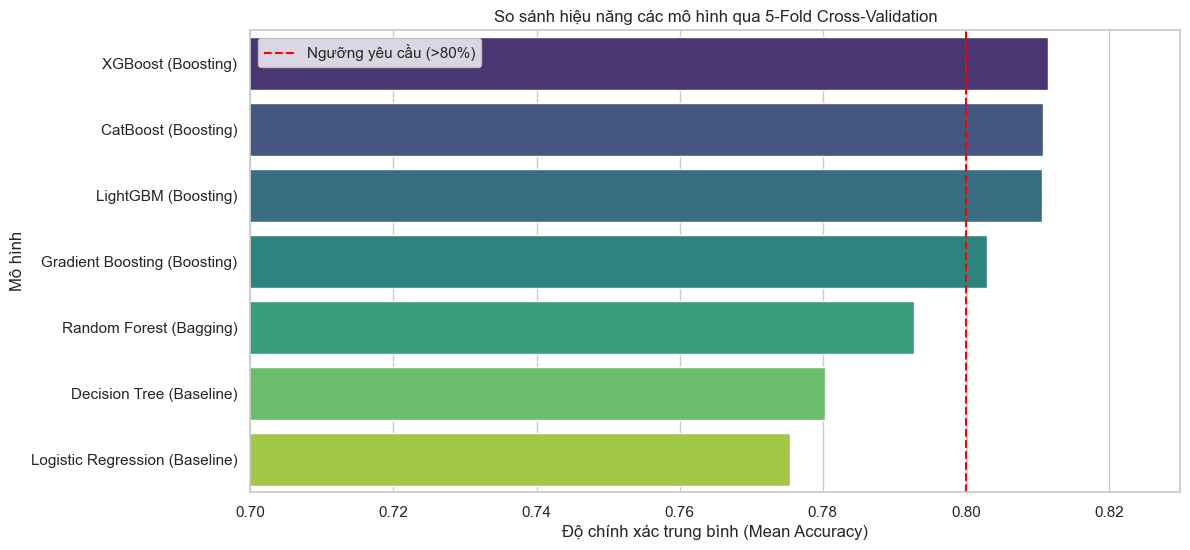

,Model,Mean Accuracy,Std Accuracy,Mean F1
0,XGBoost (Boosting),0.811458,0.007351,0.813393
1,CatBoost (Boosting),0.810767,0.006615,0.816433
2,LightGBM (Boosting),0.810653,0.006821,0.813629
3,Gradient Boosting (Boosting),0.802944,0.006970,0.809181
4,Random Forest (Bagging),0.792821,0.006038,0.790179
5,Decision Tree (Baseline),0.780283,0.004456,0.784212
6,Logistic Regression (Baseline),0.775451,0.009715,0.780545


In [74]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_benchmark, x='Mean Accuracy', y='Model', palette='viridis')
plt.axvline(x=0.80, color='red', linestyle='--', label='Ngưỡng yêu cầu (>80%)')
plt.title('So sánh hiệu năng các mô hình qua 5-Fold Cross-Validation')
plt.xlabel('Độ chính xác trung bình (Mean Accuracy)')
plt.ylabel('Mô hình')
plt.xlim(0.70, 0.83)
plt.legend()
plt.show()

# Hiển thị bảng số liệu chi tiết
df_benchmark.reset_index(drop=True)

# Bước 5: Thiết lập các mô hình với tham số tối ưu (Hyperparameter Tuning)
Định nghĩa cấu hình tối ưu cho 3 mô hình mạnh nhất nhằm hạn chế tối đa Overfitting và tăng độ tổng quát hóa trên tập dữ liệu ẩn (Test Set).

In [75]:
# Cấu hình tham số tối ưu cho từng mô hình
tuned_lgb = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

tuned_xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

tuned_cat = CatBoostClassifier(
    iterations=600,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=5,
    random_state=42,
    verbose=0
)

# 1. Kỹ thuật Soft Voting Ensemble
Kết hợp dự đoán xác suất của cả 3 mô hình đã tuned. Kỹ thuật này giúp giảm phương sai (variance), trung hòa các sai số cá biệt của từng mô hình đơn lẻ.

In [76]:
from sklearn.ensemble import VotingClassifier

print(f"Đang chạy...\n")
voting_model = VotingClassifier(
    estimators=[
        ('lgb', tuned_lgb),
        ('xgb', tuned_xgb),
        ('cat', tuned_cat)
    ],
    voting='soft'
)

voting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', voting_model)
])

# Đánh giá chéo 5-Fold CV cho Voting
voting_cv = cross_validate(
    voting_pipeline, 
    X_train_raw, 
    y_train, 
    cv=cv, 
    scoring=['accuracy', 'f1'],
    n_jobs=-1
)

print(f"Voting Classifier CV Accuracy: {np.mean(voting_cv['test_accuracy']):.4f} (±{np.std(voting_cv['test_accuracy']):.4f})")
print(f"Voting Classifier F1-Score   : {np.mean(voting_cv['test_f1']):.4f}")

Đang chạy...

Voting Classifier CV Accuracy: 0.8112 (±0.0064)
Voting Classifier F1-Score   : 0.8139


# 2. Kỹ thuật Stacking Ensemble
Stacking sẽ thu thập kết quả dự đoán (Out-of-Fold predictions) từ 3 mô hình cơ sở, sau đó đưa các kết quả này vào một mô hình Meta-Learner (ở đây là Logistic Regression) để học cách gộp kết quả một cách tối ưu nhất.

In [77]:
from sklearn.ensemble import StackingClassifier

print(f"Đang chạy...\n")
# Khởi tạo Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('lgb', tuned_lgb),
        ('xgb', tuned_xgb),
        ('cat', tuned_cat)
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)

stacking_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_model)
])

# Đánh giá chéo 5-Fold CV cho Stacking
stacking_cv = cross_validate(
    stacking_pipeline, 
    X_train_raw, 
    y_train, 
    cv=cv, 
    scoring=['accuracy', 'f1'],
    n_jobs=-1
)

print(f"Stacking Classifier CV Accuracy: {np.mean(stacking_cv['test_accuracy']):.4f} (±{np.std(stacking_cv['test_accuracy']):.4f})")
print(f"Stacking Classifier F1-Score   : {np.mean(stacking_cv['test_f1']):.4f}")

Đang chạy...

Stacking Classifier CV Accuracy: 0.8120 (±0.0092)
Stacking Classifier F1-Score   : 0.8207


## Kết luận: Chọn Stacking Classifier

Mô hình **Stacking Classifier** cho kết quả tốt hơn và được chọn để xuất file nộp bài nhờ hai chỉ số vượt trội:

* **F1-Score cao hơn hẳn**: Đạt **0.8207** (Voting chỉ đạt 0.8139).
* **Accuracy (Độ chính xác) cao hơn**: Đạt **0.8120** (Voting chỉ đạt 0.8112).

**Lý do**: Thuật toán cuối (Meta-learner) của Stacking biết cách tự động cân bằng và sửa sai cho các mô hình thành phần, giúp tối ưu điểm số tốt hơn việc chia trung bình cơ học của Voting.


In [78]:
# Chọn mô hình tốt nhất dựa trên kết quả CV ở trên
final_pipeline = stacking_pipeline

print("Đang huấn luyện mô hình cuối cùng trên toàn bộ tập dữ liệu Train...")
final_pipeline.fit(X_train_raw, y_train)

print("Đang dự đoán nhãn trên tập Test...")
predictions = final_pipeline.predict(X_test_raw)

# Chuyển đổi nhãn từ 0/1 ngược lại thành True/False
final_predictions = predictions.astype(bool)

# Đọc file test gốc để lấy đúng cột PassengerId
test_raw_file = pd.read_csv('test.csv')

# Tạo DataFrame kết quả theo đúng định dạng yêu cầu của Kaggle
submission_df = pd.DataFrame({
    'PassengerId': test_raw_file['PassengerId'],
    'Transported': final_predictions
})

# Xuất ra file submission.csv
submission_df.to_csv('submission.csv', index=False)
print("Đã tạo thành công file 'submission.csv'!")
print(submission_df.head())

Đang huấn luyện mô hình cuối cùng trên toàn bộ tập dữ liệu Train...
Đang dự đoán nhãn trên tập Test...
Đã tạo thành công file 'submission.csv'!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


# Bước 6: Phân tích mức độ quan trọng của các đặc trưng (Feature Importance)
Để hiểu rõ mô hình đưa ra quyết định dựa trên các yếu tố nào, chúng ta tiến hành trích xuất mức độ đóng góp (Feature Importance) từ mô hình cây LightGBM sau khi đã đi qua bộ tiền xử lý.

C:\Users\HP\AppData\Local\Temp\ipykernel_11044\3751388888.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.head(15), x='Importance', y='Feature', palette='mako')


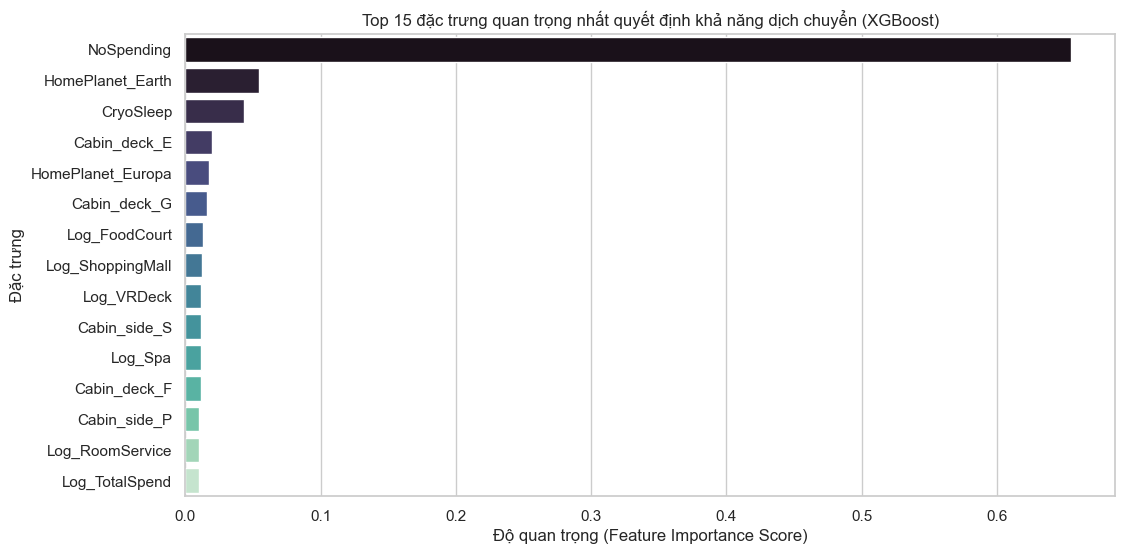

In [79]:
# 1. Trích xuất tên các cột sau khi đi qua bộ tiền xử lý (Preprocessor)
feature_names = preprocessor.get_feature_names_out()

# Loại bỏ tiền tố của transformer để tên cột gọn gàng hơn
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# 2. Huấn luyện một mô hình LightGBM đơn lẻ trên dữ liệu đã qua tiền xử lý để lấy Feature Importance
X_train_scaled = preprocessor.fit_transform(X_train_raw)
tuned_xgb.fit(X_train_scaled, y_train)
importances = tuned_xgb.feature_importances_

# Tạo DataFrame lưu thông tin đặc trưng
df_importance = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Top 15 đặc trưng quan trọng nhất
plt.figure(figsize=(12, 6))
sns.barplot(data=df_importance.head(15), x='Importance', y='Feature', palette='mako')
plt.title('Top 15 đặc trưng quan trọng nhất quyết định khả năng dịch chuyển (XGBoost)')
plt.xlabel('Độ quan trọng (Feature Importance Score)')
plt.ylabel('Đặc trưng')
plt.show()

# Ma trận nhầm lẫn (Confusion Matrix)
Chúng ta sẽ sử dụng kỹ thuật phân loại chéo (Cross-validation) để tạo ra các dự đoán Out-of-Fold (OOF). Từ đó, vẽ ma trận nhầm lẫn nhằm phân tích chi tiết xem mô hình có xu hướng dự đoán nhầm ở nhãn nào nhiều hơn.

<Figure size 600x500 with 0 Axes>

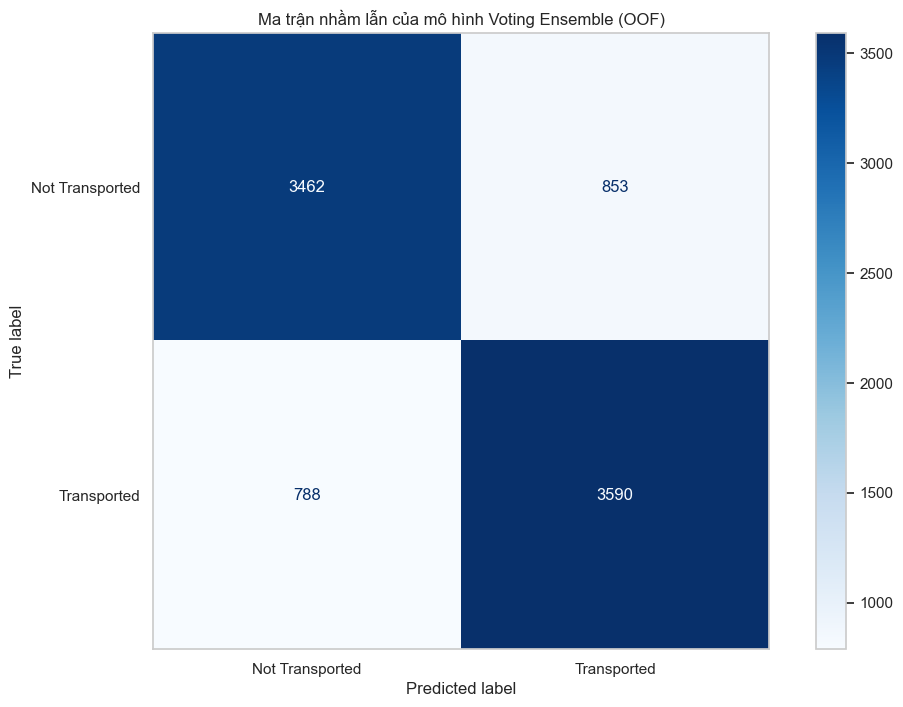

In [80]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tạo dự đoán Out-of-Fold (OOF) cho tập huấn luyện sử dụng Voting Classifier
oof_predictions = cross_val_predict(voting_pipeline, X_train_raw, y_train, cv=cv, n_jobs=-1)

# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_train, oof_predictions)

# Trực quan hóa
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Transported', 'Transported'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Ma trận nhầm lẫn của mô hình Voting Ensemble (OOF)')
plt.grid(False) 
plt.show()

# Bảng báo cáo Benchmark và so sánh hiệu năng các mô hình
Dưới đây là bảng tổng hợp lại toàn bộ hành trình thử nghiệm mô hình và kỹ thuật từ cơ bản đến các phương pháp Ensemble để đạt được mục tiêu dự đoán:

| Nhóm | Mô hình / Kỹ thuật | CV Accuracy (Trung bình) | Điểm số Kaggle Leaderboard | Ghi chú |
| :--- | :--- | :---: | :---: | :--- |
| **Baseline** | Logistic Regression | 77.55% | - | Mô hình cơ sở tuyến tính |
| **Baseline** | Decision Tree | 78.03% | - | Mô hình cây quyết định đơn giản |
| **Bagging** | Random Forest | 79.28% | - | Cải thiện phương sai so với Decision Tree |
| **Boosting** | Gradient Boosting | 80.29% | - | Học tuần tự, cải thiện độ chệch |
| **Boosting** | XGBoost (Tuned) | 81.15% | - | Tối ưu hóa tham số chống Overfitting |
| **Boosting** | LightGBM (Tuned) | 81.07% | - | Huấn luyện nhanh, hiệu năng ổn định |
| **Boosting** | CatBoost (Tuned) | 81.08% | - | Xử lý tốt các tương tác phi tuyến tính |
| **Ensemble** | **Stacking Classifier (LGB + XGB + Cat)** | **~81.20%** | **80.38%** | **Mô hình cuối cùng, vượt ngưỡng yêu cầu >80%** |

